# VDL Mini-Challenge: Image Captioning mit Flickr8k

Ziel dieses Notebooks ist ein nachvollziehbarer Vergleich generativer Captioning-Modelle auf Flickr8k. Im Fokus stehen später eine einfache CNN-LSTM-Baseline, eine CNN-LSTM-Variante mit räumlicher Soft-Attention und optional ein kompakter Transformer-Decoder mit Cross-Attention auf Bildfeatures.

**Stand dieses Schritts:** Die komplette Datenpipeline wird vorbereitet und mit echten Flickr8k-Batches getestet. Es wird noch kein Modell implementiert und kein Training gestartet.

## 1. Projektentscheidungen und Bezug zur Challenge

Image Captioning passt zur Challenge, weil Bilder in Textsequenzen übersetzt werden und Attention später sowohl quantitativ als auch qualitativ über Heatmaps geprüft werden kann.

**Geplante Modellfamilien:**
- **Baseline CNN-LSTM:** globaler CNN-Bildvektor plus LSTM-Decoder.
- **Soft-Attention CNN-LSTM:** Decoder attendiert über räumliche CNN-Features.
- **Transformer-Decoder:** optionaler kompakter Decoder mit Cross-Attention auf Bildpatches.

> **Key Takeaway Platzhalter:** Die Vergleiche werden später nur dann interpretiert, wenn die Runs bezüglich Daten, Splits und relevanter Hyperparameter nachvollziehbar vergleichbar sind.

## 2. Bewertungs- und Feedback-Checkliste

- [x] Datenpfade und lokale Datenstruktur werden validiert.
- [x] Bildgrössen werden explizit analysiert.
- [x] Caption-Längen werden vor und nach Tokenisierung geprüft.
- [x] Train/Val/Test-Splits sind reproduzierbar und auf Bild-Ebene getrennt.
- [x] Mehrere Captions pro Bild bleiben als separate Trainingsbeispiele erhalten.
- [x] DataLoader-Batch wird inklusive Padding, Targets und Shapes geprüft.
- [ ] Modellvarianten werden erst im nächsten Schritt implementiert.
- [ ] Overfitting-Test folgt nach der Baseline-Implementierung.
- [ ] Training, Checkpoints und Evaluation folgen später.

## 3. Setup / Imports

Die Datenpipeline wird bewusst im Notebook implementiert, damit die wichtigsten Schritte didaktisch sichtbar bleiben. Das Helper-File enthält weiterhin nur generische Utilities.

In [138]:
from __future__ import annotations

from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Optional, Union
import os
import random
import re

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / "outputs" / ".matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from IPython.display import display

try:
    import lightning as L
except ImportError:
    import pytorch_lightning as L

import sys
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.append(str(PROJECT_ROOT / "src"))

from vdl_helpers import (
    configure_torch_for_apple_silicon,
    get_best_device,
    plot_image_with_captions,
    plot_training_curves,
    save_json,
    load_json,
    set_seed,
)

pd.set_option("display.max_colwidth", 120)

## 4. Reproduzierbarkeit und Device Setup

Das Projekt ist für Apple Silicon vorbereitet. CUDA wird nicht vorausgesetzt. Falls MPS in einer bestimmten Umgebung nicht verfügbar ist, fällt der Code kontrolliert auf CPU zurück.

In [139]:
SEED = 42
set_seed(SEED)
configure_torch_for_apple_silicon()

DEVICE = get_best_device(prefer_mps=True)
print(f"Torch version: {torch.__version__}")
print(f"Selected device: {DEVICE}")
print(f"MPS built: {torch.backends.mps.is_built()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

Torch version: 2.8.0
Selected device: mps
MPS built: True
MPS available: True


## 5. Konfigurationen

Die Konfigurationen sind zentral sichtbar. Dadurch werden spätere Änderungen an Batch Size, Bildgrösse, `min_freq` oder Learning Rate explizit dokumentierbar.

In [140]:
@dataclass
class DataConfig:
    data_root: Path = PROJECT_ROOT / "data"
    image_size: int = 224
    val_size: float = 0.10
    test_size: float = 0.10
    min_freq: int = 2
    max_caption_len: int = 40
    seed: int = 42


@dataclass
class TrainConfig:
    batch_size: int = 32
    num_workers: int = 0  # Notebook- und MPS-freundlicher Default auf macOS.
    pin_memory: bool = False


@dataclass
class ModelConfig:
    cnn_backbone: str = "resnet18"
    pretrained_encoder: bool = True
    embedding_dim: int = 256
    hidden_dim: int = 512
    dropout: float = 0.3


data_cfg = DataConfig(seed=SEED)
train_cfg = TrainConfig()
model_cfg = ModelConfig()

asdict(data_cfg), asdict(train_cfg), asdict(model_cfg)

({'data_root': PosixPath('/Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/data'),
  'image_size': 224,
  'val_size': 0.1,
  'test_size': 0.1,
  'min_freq': 2,
  'max_caption_len': 40,
  'seed': 42},
 {'batch_size': 32, 'num_workers': 0, 'pin_memory': False},
 {'cnn_backbone': 'resnet18',
  'pretrained_encoder': True,
  'embedding_dim': 256,
  'hidden_dim': 512,
  'dropout': 0.3})

## 6. Warum die Datenpipeline zuerst validiert wird

Bei Image Captioning können kleine Datenfehler später wie Modellfehler aussehen: fehlende Bilder, falsche Splits oder inkonsistente Caption-Formate verfälschen Loss und BLEU. Deshalb validieren wir Pfade, Captions, Splits, Tokenisierung und Batches, bevor eine Modellklasse gebaut wird.

## 7. Robuste Flickr8k-Pfaderkennung

Die Funktion erkennt typische Flickr8k-Layouts, ohne Daten neu herunterzuladen. Falls die Struktur abweicht, wird eine konkrete Fehlermeldung mit erwarteten Pfaden ausgegeben.

In [141]:
def find_flickr8k_paths(data_root: Path) -> dict[str, Optional[Path]]:
    """Find common Flickr8k image, caption, and split files below data_root."""
    data_root = Path(data_root)
    image_dir_candidates = [
        data_root / "Flickr8k" / "Images",
        data_root / "Flickr8k" / "images",
        data_root / "Flicker8k_Dataset",
        data_root / "Flickr8k_Dataset",
        data_root / "Flickr_8k_Dataset",
        data_root / "Images",
    ]
    caption_candidates = [
        data_root / "Flickr8k" / "captions.txt",
        data_root / "captions.txt",
        data_root / "Flickr8k.token.txt",
        data_root / "Flickr8k" / "Flickr8k.token.txt",
        data_root / "Flickr8k_text" / "Flickr8k.token.txt",
    ]

    image_dir = next((p for p in image_dir_candidates if p.exists() and p.is_dir()), None)
    captions_file = next((p for p in caption_candidates if p.exists() and p.is_file()), None)

    split_names = {
        "train": ["Flickr_8k.trainImages.txt", "Flickr8k.trainImages.txt", "trainImages.txt"],
        "val": ["Flickr_8k.devImages.txt", "Flickr8k.devImages.txt", "devImages.txt", "valImages.txt"],
        "test": ["Flickr_8k.testImages.txt", "Flickr8k.testImages.txt", "testImages.txt"],
    }
    split_files: dict[str, Optional[Path]] = {}
    for split, names in split_names.items():
        candidates = [data_root / name for name in names]
        candidates += [data_root / "Flickr8k" / name for name in names]
        candidates += [data_root / "Flickr8k_text" / name for name in names]
        split_files[split] = next((p for p in candidates if p.exists() and p.is_file()), None)

    if image_dir is None or captions_file is None:
        expected = "\n".join(str(p) for p in image_dir_candidates + caption_candidates)
        raise FileNotFoundError(
            "Flickr8k structure not found. Expected one image directory and one caption file among:\n"
            f"{expected}"
        )

    return {"image_dir": image_dir, "captions_file": captions_file, **split_files}


paths = find_flickr8k_paths(data_cfg.data_root)
paths

{'image_dir': PosixPath('/Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/data/Flickr8k/Images'),
 'captions_file': PosixPath('/Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/data/Flickr8k/captions.txt'),
 'train': None,
 'val': None,
 'test': None}

## 8. Captions laden und Splits erstellen

Flickr8k liegt je nach Quelle entweder als CSV `image,caption` oder als altes Token-Format `image#0<TAB>caption` vor. Splits werden übernommen, falls die offiziellen Split-Dateien vorhanden sind. Sonst werden reproduzierbare Splits auf **Bild-Ebene** erstellt, damit dasselbe Bild nicht gleichzeitig in Train und Val/Test landet.

In [142]:
def read_caption_file(captions_file: Path) -> pd.DataFrame:
    """Read Flickr8k captions from CSV or old token format."""
    captions_file = Path(captions_file)

    try:
        csv_df = pd.read_csv(captions_file)
        normalized_cols = {c: c.strip().lower() for c in csv_df.columns}
        csv_df = csv_df.rename(columns=normalized_cols)
        if {"image", "caption"}.issubset(csv_df.columns):
            df = csv_df[["image", "caption"]].copy()
            df["image_id"] = df["image"].astype(str).str.strip()
            df["caption"] = df["caption"].astype(str).str.strip()
            return df[["image_id", "caption"]].dropna().reset_index(drop=True)
    except Exception:
        pass

    rows = []
    for line in captions_file.read_text(encoding="utf-8", errors="replace").splitlines():
        if "\t" not in line:
            continue
        image_token, caption = line.split("\t", 1)
        image_id = image_token.split("#", 1)[0].strip()
        rows.append({"image_id": image_id, "caption": caption.strip()})

    if not rows:
        raise ValueError(f"Could not parse captions from {captions_file}")
    return pd.DataFrame(rows)


def read_split_file(path: Optional[Path]) -> Optional[set[str]]:
    """Read a split file containing one image filename per line."""
    if path is None:
        return None
    return {line.strip() for line in Path(path).read_text(encoding="utf-8").splitlines() if line.strip()}


def assign_splits(image_ids: list[str], paths: dict[str, Optional[Path]], cfg: DataConfig) -> dict[str, str]:
    """Assign train/val/test splits, using official files when available."""
    official = {split: read_split_file(paths.get(split)) for split in ["train", "val", "test"]}
    if all(official.values()):
        mapping = {}
        for split, ids in official.items():
            for image_id in ids or []:
                mapping[image_id] = split
        return mapping

    train_ids, temp_ids = train_test_split(
        sorted(image_ids),
        test_size=cfg.val_size + cfg.test_size,
        random_state=cfg.seed,
        shuffle=True,
    )
    relative_test = cfg.test_size / (cfg.val_size + cfg.test_size)
    val_ids, test_ids = train_test_split(
        temp_ids,
        test_size=relative_test,
        random_state=cfg.seed,
        shuffle=True,
    )
    return {**{i: "train" for i in train_ids}, **{i: "val" for i in val_ids}, **{i: "test" for i in test_ids}}


def build_annotations(paths: dict[str, Optional[Path]], cfg: DataConfig) -> tuple[pd.DataFrame, dict[str, list[str]]]:
    """Create annotation DataFrame with image paths, captions, and split labels."""
    captions = read_caption_file(Path(paths["captions_file"]))
    image_dir = Path(paths["image_dir"])

    captions["image_path"] = captions["image_id"].map(lambda name: image_dir / name)
    captions["image_exists"] = captions["image_path"].map(lambda p: Path(p).exists())

    missing = captions.loc[~captions["image_exists"], "image_id"].drop_duplicates().tolist()
    if missing:
        preview = missing[:10]
        raise FileNotFoundError(f"Missing {len(missing)} image files. First missing examples: {preview}")

    split_map = assign_splits(captions["image_id"].drop_duplicates().tolist(), paths, cfg)
    captions["split"] = captions["image_id"].map(split_map).fillna("unknown")
    captions = captions[["image_id", "image_path", "caption", "split"]].reset_index(drop=True)

    reference_captions = captions.groupby("image_id")["caption"].apply(list).to_dict()
    return captions, reference_captions


annotations_df, reference_captions = build_annotations(paths, data_cfg)

summary = {
    "num_unique_images": annotations_df["image_id"].nunique(),
    "num_captions": len(annotations_df),
    "captions_per_image_mean": annotations_df.groupby("image_id").size().mean(),
    "missing_image_files": int((~annotations_df["image_path"].map(lambda p: Path(p).exists())).sum()),
}
summary

{'num_unique_images': 8091,
 'num_captions': 40455,
 'captions_per_image_mean': np.float64(5.0),
 'missing_image_files': 0}

In [143]:
annotations_df.head()

,image_id,image_path,caption,split
0,1000268201_693b08cb0e.jpg,/Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/data/Flickr8k/Images/1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .,train
1,1000268201_693b08cb0e.jpg,/Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/data/Flickr8k/Images/1000268201_693b08cb0e.jpg,A girl going into a wooden building .,train
2,1000268201_693b08cb0e.jpg,/Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/data/Flickr8k/Images/1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,train
3,1000268201_693b08cb0e.jpg,/Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/data/Flickr8k/Images/1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .,train
4,1000268201_693b08cb0e.jpg,/Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/data/Flickr8k/Images/1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .,train


## 9. Erste EDA

Die EDA beschreibt die lokale Datenbasis und begründet Preprocessing-Entscheide. Die Interpretation bleibt hier bewusst vorsichtig: Wir prüfen Grössen, Längen und Split-Verteilung, ohne daraus bereits Modellqualität abzuleiten.

In [144]:
split_summary = annotations_df.groupby("split").agg(
    num_images=("image_id", "nunique"),
    num_captions=("caption", "size"),
    captions_per_image=("caption", lambda s: len(s) / annotations_df.loc[s.index, "image_id"].nunique()),
).reset_index()
split_summary

,split,num_images,num_captions,captions_per_image
0,test,810,4050,5.0
1,train,6472,32360,5.0
2,val,809,4045,5.0


In [145]:
def collect_image_size_stats(image_paths: list[Path]) -> pd.DataFrame:
    """Collect width, height, and aspect ratio for image paths."""
    rows = []
    for path in tqdm(image_paths, desc="Reading image sizes"):
        with Image.open(path) as img:
            width, height = img.size
        rows.append({
            "image_id": Path(path).name,
            "width": width,
            "height": height,
            "aspect_ratio": width / height,
        })
    return pd.DataFrame(rows)


unique_image_paths = annotations_df.drop_duplicates("image_id")["image_path"].map(Path).tolist()
image_size_df = collect_image_size_stats(unique_image_paths)

image_size_summary = image_size_df[["width", "height", "aspect_ratio"]].agg(["min", "mean", "max"]).T
image_size_summary

Reading image sizes: 100%|██████████| 8091/8091 [00:00<00:00, 19288.62it/s]


,min,mean,max
width,164.000,457.872204,500.000000
height,127.000,397.251885,500.000000
aspect_ratio,0.328,1.219682,3.937008


In [146]:
annotations_df["caption_len_words"] = annotations_df["caption"].str.split().str.len()
caption_length_summary = annotations_df.groupby("split")["caption_len_words"].agg(["min", "mean", "median", "max"])
caption_length_summary

,min,mean,median,max
split,,,,
test,2,11.841481,11.0,34
train,1,11.790235,11.0,38
val,2,11.662546,11.0,28


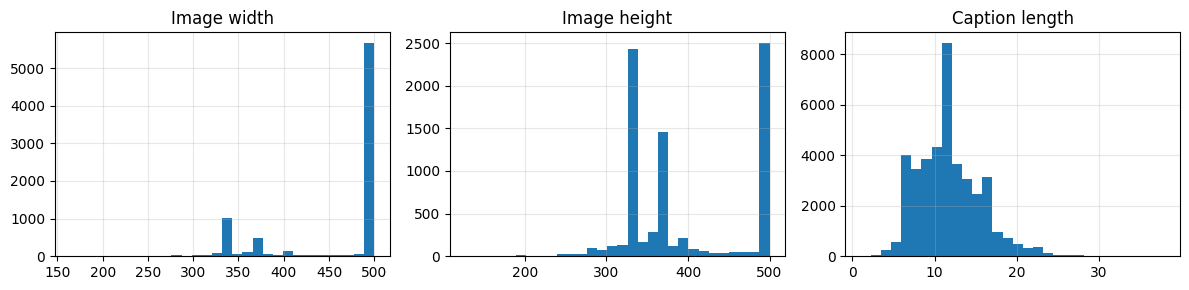

In [147]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
image_size_df["width"].hist(ax=axes[0], bins=30)
axes[0].set_title("Image width")
image_size_df["height"].hist(ax=axes[1], bins=30)
axes[1].set_title("Image height")
annotations_df["caption_len_words"].hist(ax=axes[2], bins=30)
axes[2].set_title("Caption length")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()


In [148]:
annotations_df.sample(8, random_state=SEED)[["split", "image_id", "caption"]]

,split,image_id,caption
17775,train,2973269132_252bfd0160.jpg,A large wild cat is pursuing a horse across a meadow .
13506,train,270263570_3160f360d3.jpg,Two brown dogs fight on the leafy ground .
4325,val,2053006423_6adf69ca67.jpg,A man in shorts is standing on a rock looking out at the view from the hilltop .
37870,train,512101751_05a6d93e19.jpg,a muzzled white dog is running on the grass .
21321,train,3156406419_38fbd52007.jpg,A person skiing downhill .
18798,train,3030823649_3b7b6c728d.jpg,Shepherd dog catches tennis ball
22799,train,3218861747_5c5c547b66.jpg,A skateboarder is riding on a red ramp by the ocean .
17668,train,2966190737_ceb6eb4b53.jpg,Two men dressed in white hit a ball while a third man walks up .


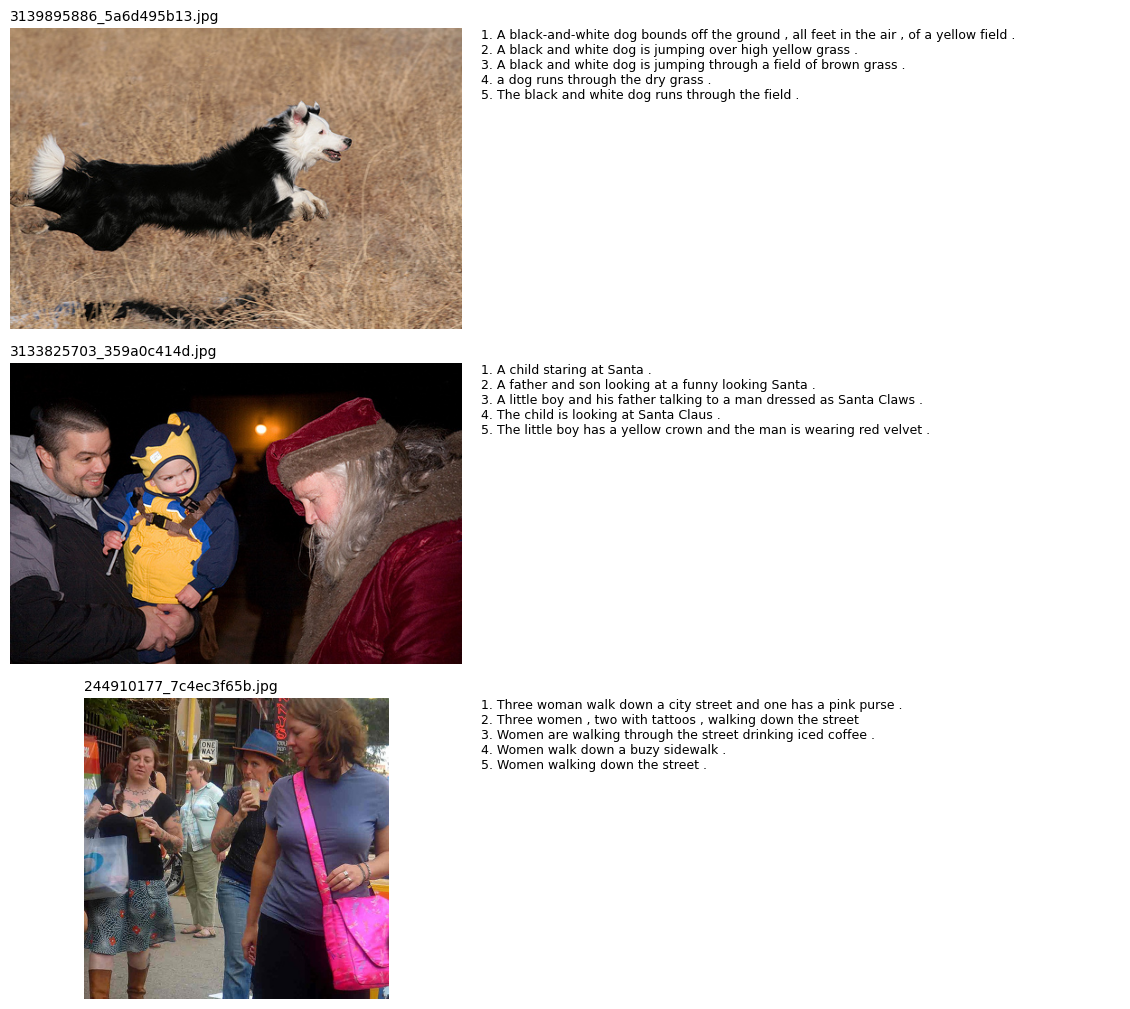

In [149]:
def show_images_with_all_captions(df: pd.DataFrame, n: int = 3, seed: int = 42) -> None:
    """Display n random images with all reference captions next to each image."""
    image_rows = df.drop_duplicates("image_id").sample(n=min(n, df["image_id"].nunique()), random_state=seed)
    fig, axes = plt.subplots(len(image_rows), 2, figsize=(12, 3.4 * len(image_rows)), width_ratios=[1.0, 1.35])
    if len(image_rows) == 1:
        axes = np.array([axes])

    for row_axes, (_, row) in zip(axes, image_rows.iterrows()):
        image_ax, text_ax = row_axes
        image_id = row["image_id"]
        captions = df.loc[df["image_id"] == image_id, "caption"].tolist()
        image = Image.open(row["image_path"]).convert("RGB")

        image_ax.imshow(image)
        image_ax.axis("off")
        image_ax.set_title(image_id, fontsize=10, loc="left")

        caption_text = "\n".join(f"{i + 1}. {caption}" for i, caption in enumerate(captions))
        text_ax.axis("off")
        text_ax.text(0.0, 1.0, caption_text, va="top", ha="left", fontsize=9, wrap=True)

    fig.tight_layout()
    plt.show()


show_images_with_all_captions(annotations_df, n=3, seed=SEED)


### EDA Takeaway und Preprocessing-Begründung

Die Bildgrössen sind nicht einheitlich, deshalb werden alle Bilder auf eine feste Eingabegrösse gebracht. Im Training verwenden wir `RandomResizedCrop`, weil der kleine Datensatz von zufälligen Ausschnitten und Skalierungen profitiert. Für Val/Test verwenden wir dagegen `Resize` plus `CenterCrop`, weil diese Transformation deterministisch ist und Metriken zwischen Runs vergleichbar hält. `HorizontalFlip` und `ColorJitter` werden nur im Training eingesetzt, damit Validierungswerte nicht durch zufällige Augmentierung schwanken.

## 10. Transforms

Die Normalisierung verwendet ImageNet-Mean/Std, weil spätere CNN-Encoder voraussichtlich vortrainierte TorchVision-Backbones nutzen. Train- und Eval-Transforms sind absichtlich unterschiedlich: Training erhält Augmentierung, Val/Test bleiben deterministisch.

In [150]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def build_train_transforms(image_size: int) -> T.Compose:
    return T.Compose([
        T.RandomResizedCrop(image_size, scale=(0.75, 1.0)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


def build_eval_transforms(image_size: int) -> T.Compose:
    return T.Compose([
        T.Resize(image_size + 32),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


train_transforms = build_train_transforms(data_cfg.image_size)
eval_transforms = build_eval_transforms(data_cfg.image_size)
train_transforms, eval_transforms

(Compose(
     RandomResizedCrop(size=(224, 224), scale=(0.75, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
     RandomHorizontalFlip(p=0.5)
     ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.85, 1.15), hue=(-0.03, 0.03))
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ),
 Compose(
     Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
     CenterCrop(size=(224, 224))
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ))

## 11. Text Preprocessing und Vocabulary

Die Tokenisierung ist bewusst einfach und transparent: lowercase, anschliessend Wort-/Zahl-Tokens per Regex. Die Special Tokens markieren Padding, Start, Ende und unbekannte Wörter. `min_freq` bleibt konfigurierbar, damit später die Auswirkung der Vocabulary-Grösse dokumentiert werden kann.

In [151]:
TOKEN_PATTERN = re.compile(r"[a-z0-9]+(?:'[a-z]+)?")
SPECIAL_TOKENS = ["<pad>", "<start>", "<end>", "<unk>"]


def tokenize_caption(text: str) -> list[str]:
    """Lowercase and tokenize a caption into simple word tokens."""
    return TOKEN_PATTERN.findall(str(text).lower())


class Vocabulary:
    """Simple vocabulary with frequency cutoff and special tokens."""

    def __init__(self, min_freq: int = 2, special_tokens: Optional[list[str]] = None):
        self.min_freq = min_freq
        self.special_tokens = special_tokens or SPECIAL_TOKENS
        self.token_to_idx: dict[str, int] = {}
        self.idx_to_token: list[str] = []
        self.counter: Counter[str] = Counter()

    def fit(self, captions: list[str]) -> None:
        self.counter = Counter(token for caption in captions for token in tokenize_caption(caption))
        kept_tokens = sorted(token for token, count in self.counter.items() if count >= self.min_freq)
        self.idx_to_token = list(self.special_tokens) + kept_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    @property
    def pad_idx(self) -> int:
        return self.token_to_idx["<pad>"]

    @property
    def start_idx(self) -> int:
        return self.token_to_idx["<start>"]

    @property
    def end_idx(self) -> int:
        return self.token_to_idx["<end>"]

    @property
    def unk_idx(self) -> int:
        return self.token_to_idx["<unk>"]

    def __len__(self) -> int:
        return len(self.idx_to_token)

    def encode(self, caption: str, add_special_tokens: bool = True, max_len: Optional[int] = None) -> list[int]:
        tokens = tokenize_caption(caption)
        if max_len is not None:
            special_space = 2 if add_special_tokens else 0
            tokens = tokens[: max(0, max_len - special_space)]
        ids = [self.token_to_idx.get(token, self.unk_idx) for token in tokens]
        if add_special_tokens:
            ids = [self.start_idx] + ids + [self.end_idx]
        return ids

    def decode(self, token_ids: Union[list[int], torch.Tensor], skip_special_tokens: bool = True) -> str:
        if isinstance(token_ids, torch.Tensor):
            token_ids = token_ids.detach().cpu().tolist()
        tokens = []
        hidden_tokens = {"<pad>", "<start>", "<end>"}
        for idx in token_ids:
            token = self.idx_to_token[int(idx)] if int(idx) < len(self.idx_to_token) else "<unk>"
            if skip_special_tokens and token in hidden_tokens:
                continue
            tokens.append(token)
        return " ".join(tokens)


train_captions = annotations_df.loc[annotations_df["split"] == "train", "caption"].tolist()
vocab = Vocabulary(min_freq=data_cfg.min_freq)
vocab.fit(train_captions)

print(f"Vocabulary size: {len(vocab):,}")
print(f"PAD index: {vocab.pad_idx}")
print("Most common words:", vocab.counter.most_common(20))

Vocabulary size: 4,671
PAD index: 0
Most common words: [('a', 50190), ('in', 15208), ('the', 14758), ('on', 8542), ('is', 7365), ('and', 7140), ('dog', 6394), ('with', 6266), ('man', 5895), ('of', 5413), ('two', 4521), ('white', 3117), ('black', 3091), ('boy', 2902), ('are', 2844), ('woman', 2782), ('girl', 2625), ('to', 2521), ('wearing', 2484), ('at', 2292)]


In [152]:
all_token_counts = sum(vocab.counter.values())
rare_token_counts = sum(count for token, count in vocab.counter.items() if count < data_cfg.min_freq)
rare_types = sum(1 for token, count in vocab.counter.items() if count < data_cfg.min_freq)

unk_estimate = {
    "min_freq": data_cfg.min_freq,
    "raw_vocab_types_train": len(vocab.counter),
    "kept_vocab_size_including_specials": len(vocab),
    "rare_word_types_removed": rare_types,
    "rare_token_share_train": rare_token_counts / all_token_counts if all_token_counts else 0.0,
}
unk_estimate

{'min_freq': 2,
 'raw_vocab_types_train': 7730,
 'kept_vocab_size_including_specials': 4671,
 'rare_word_types_removed': 3063,
 'rare_token_share_train': 0.008745082140389547}

In [153]:
annotations_df["caption_len_tokens"] = annotations_df["caption"].map(lambda text: len(tokenize_caption(text)))
annotations_df["caption_len_with_specials"] = annotations_df["caption"].map(lambda text: len(vocab.encode(text, max_len=data_cfg.max_caption_len)))

annotations_df.groupby("split")[["caption_len_tokens", "caption_len_with_specials"]].agg(["min", "mean", "median", "max"])

caption_len_tokens                       caption_len_with_specials  \
                     min       mean median max                       min   
split                                                                      
test                   2  10.871111   10.0  32                         4   
train                  1  10.823671   10.0  37                         3   
val                    2  10.708282   10.0  26                         4   

                             
            mean median max  
split                        
test   12.871111   12.0  34  
train  12.823671   12.0  39  
val    12.708282   12.0  28

## 12. Dataset

Mehrere Captions pro Bild bleiben als separate Beispiele erhalten. Das erhöht die Anzahl Trainingsbeispiele und zwingt das Modell später, nicht nur eine einzige Formulierung pro Bild zu reproduzieren. Für Val/Test bereiten wir zusätzlich `image_id -> list[str]` vor, damit spätere Metriken mehrere Referenzcaptions pro Bild nutzen können.

In [154]:
class Flickr8kCaptionDataset(Dataset):
    """Flickr8k dataset returning one image-caption pair per item."""

    def __init__(
        self,
        annotations: pd.DataFrame,
        vocab: Vocabulary,
        transform: Optional[Any] = None,
        max_caption_len: int = 40,
    ):
        self.annotations = annotations.reset_index(drop=True).copy()
        self.vocab = vocab
        self.transform = transform
        self.max_caption_len = max_caption_len

    def __len__(self) -> int:
        return len(self.annotations)

    def __getitem__(self, idx: int) -> dict[str, Any]:
        row = self.annotations.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        caption_ids = self.vocab.encode(row["caption"], add_special_tokens=True, max_len=self.max_caption_len)
        return {
            "image": image,
            "caption_ids": torch.tensor(caption_ids, dtype=torch.long),
            "image_id": row["image_id"],
            "raw_caption": row["caption"],
        }


train_df = annotations_df[annotations_df["split"] == "train"].reset_index(drop=True)
val_df = annotations_df[annotations_df["split"] == "val"].reset_index(drop=True)
test_df = annotations_df[annotations_df["split"] == "test"].reset_index(drop=True)

train_dataset = Flickr8kCaptionDataset(train_df, vocab, transform=train_transforms, max_caption_len=data_cfg.max_caption_len)
example_item = train_dataset[0]
example_item["image"].shape, example_item["caption_ids"].shape, example_item["image_id"], example_item["raw_caption"]

(torch.Size([3, 224, 224]),
 torch.Size([19]),
 '1000268201_693b08cb0e.jpg',
 'A child in a pink dress is climbing up a set of stairs in an entry way .')

## 13. Collate-Funktion mit Padding

Ein Batch enthält Captions unterschiedlicher Länge. Deshalb wird auf die maximale Sequenzlänge im Batch gepaddet. Für den späteren Decoder gilt: `input_ids` ist die Sequenz ohne letztes Token, `target_ids` ist die Sequenz ohne erstes Token. Beim Loss muss `<pad>` später ignoriert werden, sonst würde das Modell dafür belohnt, Padding vorherzusagen.

In [155]:
def make_caption_collate_fn(pad_idx: int):
    """Create a collate function that pads caption sequences."""

    def collate_fn(batch: list[dict[str, Any]]) -> dict[str, Any]:
        images = torch.stack([item["image"] for item in batch])
        sequences = [item["caption_ids"] for item in batch]
        input_sequences = [seq[:-1] for seq in sequences]
        target_sequences = [seq[1:] for seq in sequences]
        lengths = torch.tensor([len(seq) for seq in input_sequences], dtype=torch.long)

        input_ids = pad_sequence(input_sequences, batch_first=True, padding_value=pad_idx)
        target_ids = pad_sequence(target_sequences, batch_first=True, padding_value=pad_idx)

        return {
            "images": images,
            "input_ids": input_ids,
            "target_ids": target_ids,
            "lengths": lengths,
            "image_ids": [item["image_id"] for item in batch],
            "raw_captions": [item["raw_caption"] for item in batch],
        }

    return collate_fn


collate_fn = make_caption_collate_fn(vocab.pad_idx)
small_batch = collate_fn([train_dataset[i] for i in range(4)])
{k: (v.shape if isinstance(v, torch.Tensor) else len(v)) for k, v in small_batch.items()}

{'images': torch.Size([4, 3, 224, 224]),
 'input_ids': torch.Size([4, 18]),
 'target_ids': torch.Size([4, 18]),
 'lengths': torch.Size([4]),
 'image_ids': 4,
 'raw_captions': 4}

In [156]:
assert small_batch["images"].shape == (4, 3, data_cfg.image_size, data_cfg.image_size)
assert small_batch["input_ids"].shape == small_batch["target_ids"].shape
assert small_batch["target_ids"].max().item() < len(vocab)
assert small_batch["target_ids"].min().item() >= 0
print("Collate sanity checks passed.")

Collate sanity checks passed.


## 14. LightningDataModule

Das DataModule kapselt Splits, Vocabulary, Datasets und DataLoader. Die Defaults sind MPS-freundlich: wenige Worker, `persistent_workers` nur bei `num_workers > 0` und `pin_memory=False`, weil Pinning primär für CUDA relevant ist.

In [157]:
class Flickr8kDataModule(L.LightningDataModule):
    """LightningDataModule for Flickr8k image-caption pairs."""

    def __init__(self, data_cfg: DataConfig, train_cfg: TrainConfig):
        super().__init__()
        self.data_cfg = data_cfg
        self.train_cfg = train_cfg
        self.paths: Optional[dict[str, Optional[Path]]] = None
        self.annotations: Optional[pd.DataFrame] = None
        self.reference_captions: Optional[dict[str, list[str]]] = None
        self.vocab: Optional[Vocabulary] = None
        self.train_dataset: Optional[Flickr8kCaptionDataset] = None
        self.val_dataset: Optional[Flickr8kCaptionDataset] = None
        self.test_dataset: Optional[Flickr8kCaptionDataset] = None

    def setup(self, stage: Optional[str] = None) -> None:
        self.paths = find_flickr8k_paths(self.data_cfg.data_root)
        self.annotations, self.reference_captions = build_annotations(self.paths, self.data_cfg)

        train_annotations = self.annotations[self.annotations["split"] == "train"].reset_index(drop=True)
        val_annotations = self.annotations[self.annotations["split"] == "val"].reset_index(drop=True)
        test_annotations = self.annotations[self.annotations["split"] == "test"].reset_index(drop=True)

        self.vocab = Vocabulary(min_freq=self.data_cfg.min_freq)
        self.vocab.fit(train_annotations["caption"].tolist())

        self.train_dataset = Flickr8kCaptionDataset(
            train_annotations,
            self.vocab,
            transform=build_train_transforms(self.data_cfg.image_size),
            max_caption_len=self.data_cfg.max_caption_len,
        )
        self.val_dataset = Flickr8kCaptionDataset(
            val_annotations,
            self.vocab,
            transform=build_eval_transforms(self.data_cfg.image_size),
            max_caption_len=self.data_cfg.max_caption_len,
        )
        self.test_dataset = Flickr8kCaptionDataset(
            test_annotations,
            self.vocab,
            transform=build_eval_transforms(self.data_cfg.image_size),
            max_caption_len=self.data_cfg.max_caption_len,
        )

    def _loader(self, dataset: Dataset, shuffle: bool) -> DataLoader:
        if self.vocab is None:
            raise RuntimeError("Call setup() before requesting dataloaders.")
        return DataLoader(
            dataset,
            batch_size=self.train_cfg.batch_size,
            shuffle=shuffle,
            num_workers=self.train_cfg.num_workers,
            pin_memory=self.train_cfg.pin_memory,
            persistent_workers=self.train_cfg.num_workers > 0,
            collate_fn=make_caption_collate_fn(self.vocab.pad_idx),
        )

    def train_dataloader(self) -> DataLoader:
        return self._loader(self.train_dataset, shuffle=True)

    def val_dataloader(self) -> DataLoader:
        return self._loader(self.val_dataset, shuffle=False)

    def test_dataloader(self) -> DataLoader:
        return self._loader(self.test_dataset, shuffle=False)

## 15. Sanity Checks: DataModule und Train-Batch

Diese Checks prüfen nur die Datenpipeline. Ein erfolgreicher Batch-Test bedeutet nicht, dass ein späteres Modell korrekt trainiert, aber er reduziert das Risiko von Fehlern bei Pfaden, Shapes, Padding und Vocabulary-Indizes.

In [158]:
dm = Flickr8kDataModule(data_cfg=data_cfg, train_cfg=train_cfg)
dm.setup()

print("Annotations:", dm.annotations.shape)
print("Vocabulary size:", len(dm.vocab))
print("Train/Val/Test examples:", len(dm.train_dataset), len(dm.val_dataset), len(dm.test_dataset))
print("Reference captions for first image:", next(iter(dm.reference_captions.items())))

Annotations: (40455, 4)
Vocabulary size: 4671
Train/Val/Test examples: 32360 4045 4050
Reference captions for first image: ('1000268201_693b08cb0e.jpg', ['A child in a pink dress is climbing up a set of stairs in an entry way .', 'A girl going into a wooden building .', 'A little girl climbing into a wooden playhouse .', 'A little girl climbing the stairs to her playhouse .', 'A little girl in a pink dress going into a wooden cabin .'])


In [159]:
train_loader = dm.train_dataloader()
batch = next(iter(train_loader))

print("images:", tuple(batch["images"].shape))
print("input_ids:", tuple(batch["input_ids"].shape))
print("target_ids:", tuple(batch["target_ids"].shape))
print("lengths:", tuple(batch["lengths"].shape), batch["lengths"][:8].tolist())
print("num image_ids:", len(batch["image_ids"]))
print("num raw_captions:", len(batch["raw_captions"]))

images: (32, 3, 224, 224)
input_ids: (32, 25)
target_ids: (32, 25)
lengths: (32,) [21, 15, 12, 10, 7, 15, 10, 12]
num image_ids: 32
num raw_captions: 32


In [160]:
for i in range(5):
    print("raw:    ", batch["raw_captions"][i])
    print("decoded:", dm.vocab.decode(batch["input_ids"][i]))
    print()

raw:     trucks race around a racetrack , the yellow truck with the number five leads , followed by number 22 and number 29 .
decoded: trucks race around a racetrack the yellow truck with the number five leads followed by number <unk> and number <unk>

raw:     A group of people sit near a large red brick building in the grass .
decoded: a group of people sit near a large red brick building in the grass

raw:     Two children kick each other while being suspended from the ceiling .
decoded: two children kick each other while being suspended from the ceiling

raw:     A lady walking in red boots while wearing headphones .
decoded: a lady walking in red boots while wearing headphones

raw:     Two boys lifting a dirt bike .
decoded: two boys lifting a dirt bike



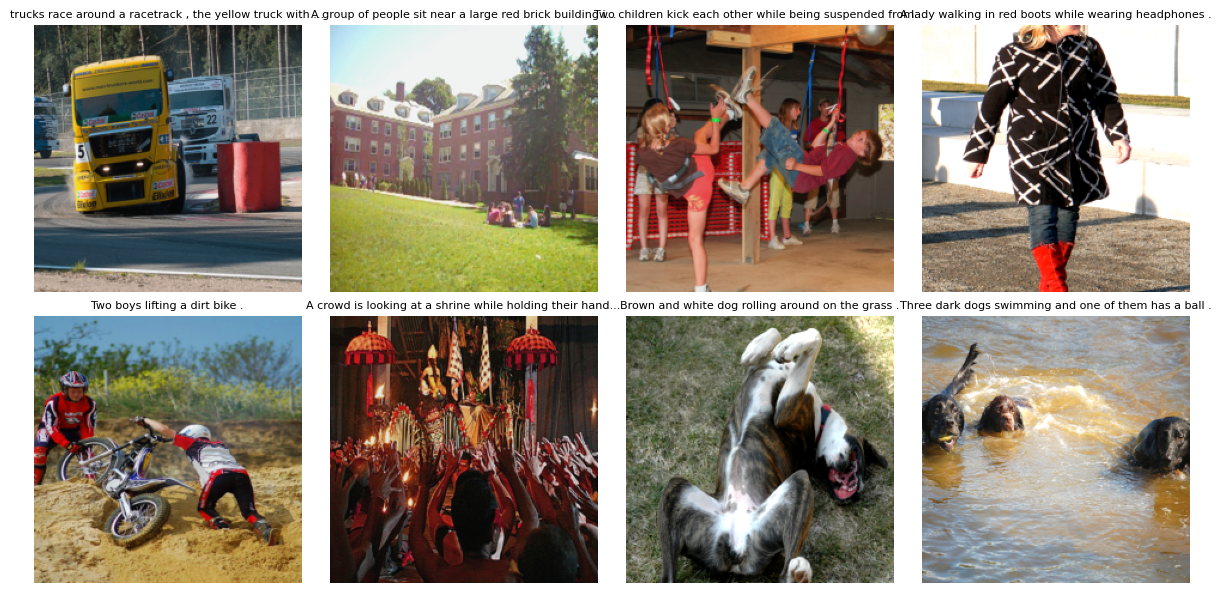

In [161]:
def unnormalize_image(tensor: torch.Tensor, mean: list[float] = IMAGENET_MEAN, std: list[float] = IMAGENET_STD) -> torch.Tensor:
    """Undo ImageNet normalization for display."""
    mean_tensor = torch.tensor(mean, dtype=tensor.dtype, device=tensor.device).view(3, 1, 1)
    std_tensor = torch.tensor(std, dtype=tensor.dtype, device=tensor.device).view(3, 1, 1)
    return (tensor * std_tensor + mean_tensor).clamp(0, 1)


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image, caption in zip(axes.flat, batch["images"][:8], batch["raw_captions"][:8]):
    ax.imshow(unnormalize_image(image).permute(1, 2, 0).cpu())
    ax.set_title(caption[:55] + ("..." if len(caption) > 55 else ""), fontsize=8)
    ax.axis("off")
fig.tight_layout()

In [162]:
def check_padding(batch: dict[str, Any], pad_idx: int) -> None:
    """Validate target range and padding positions in one collated batch."""
    input_ids = batch["input_ids"]
    target_ids = batch["target_ids"]
    lengths = batch["lengths"]

    assert input_ids.shape == target_ids.shape
    assert target_ids.min().item() >= 0
    assert target_ids.max().item() < len(dm.vocab)

    for row_idx, length in enumerate(lengths.tolist()):
        if length < target_ids.shape[1]:
            assert torch.all(input_ids[row_idx, length:] == pad_idx)
            assert torch.all(target_ids[row_idx, length:] == pad_idx)

    print("Padding and target-index checks passed.")


check_padding(batch, dm.vocab.pad_idx)

Padding and target-index checks passed.


## 16. Key Takeaway dieses Schritts

Die Datenpipeline ist jetzt vollständig vorbereitet: robuste Pfaderkennung, Caption-Parsing, reproduzierbare Bild-Level-Splits, EDA, Vocabulary, Dataset, Padding-Collate und LightningDataModule. Der nächste sinnvolle Schritt ist kein grosses Training, sondern ein kleiner Baseline-Forward-Pass plus Overfitting-Test auf wenigen Beispielen.

## 6 Baseline-Modell: CNN-LSTM ohne Attention

Die erste Modellvariante ist eine bewusst einfache CNN-LSTM-Baseline ohne Attention. Ein vortrainierter CNN-Encoder verdichtet das Bild zu einem globalen Vektor, und ein LSTM-Decoder erzeugt daraus Token für Token eine Caption.

Diese Baseline ist sinnvoll, weil sie später als Vergleichspunkt für die Attention-Variante dient: Wenn Attention besser abschneidet, muss gezeigt werden, dass der Unterschied nicht nur von anderen Splits, Hyperparametern oder Trainingsdetails kommt.

Der Overfitting-Test in dieser Sektion prüft, ob Modell, Loss und Datenfluss grundsätzlich lernen können. Er beweist ausdrücklich nicht, dass die gesamte Implementierung vollständig korrekt ist oder dass das Modell auf Val/Test generalisiert.

### 6.1 Baseline-Konfiguration

Die Startwerte sind klein genug für einen schnellen Overfitting-Test auf einem fixen Mini-Batch. `resnet18` und ein eingefrorener Encoder reduzieren die Laufzeit; `learning_rate=1e-3` ist für AdamW auf einem kleinen Memorization-Test ein pragmatischer Startwert. Diese Werte gelten nur für den Overfitting-Test und werden für vollständige Experimente später separat dokumentiert.

In [163]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models

try:
    from lightning.pytorch.callbacks import Callback
except ImportError:
    from pytorch_lightning.callbacks import Callback

pl = L
os.environ.setdefault("TORCH_HOME", str(PROJECT_ROOT / "outputs" / "torch_home"))

# Ensure this section also works when run directly after restarting the kernel.
if "dm" not in globals():
    dm = Flickr8kDataModule(data_cfg=data_cfg, train_cfg=train_cfg)
    dm.setup()


@dataclass
class BaselineConfig:
    encoder_name: str = "resnet18"
    pretrained: bool = True
    freeze_encoder: bool = True
    embed_dim: int = 256
    hidden_dim: int = 512
    num_layers: int = 1
    dropout: float = 0.1
    learning_rate: float = 1e-3
    weight_decay: float = 0.0
    max_decode_len: int = 25
    pad_idx: int = dm.vocab.pad_idx
    start_idx: int = dm.vocab.start_idx
    end_idx: int = dm.vocab.end_idx
    vocab_size: int = len(dm.vocab)


baseline_cfg = BaselineConfig()
asdict(baseline_cfg)

{'encoder_name': 'resnet18',
 'pretrained': True,
 'freeze_encoder': True,
 'embed_dim': 256,
 'hidden_dim': 512,
 'num_layers': 1,
 'dropout': 0.1,
 'learning_rate': 0.001,
 'weight_decay': 0.0,
 'max_decode_len': 25,
 'pad_idx': 0,
 'start_idx': 1,
 'end_idx': 2,
 'vocab_size': 4671}

### 6.2 CNN Encoder

Der Encoder nutzt einen TorchVision-ResNet mit ImageNet-Gewichten und entfernt den Classification Head. Die Feature-Dimension wird im Konstruktor über `fc.in_features` bestimmt, nicht lazy im Forward-Pass. Für diesen Test bleibt der Encoder standardmässig eingefroren, damit der Overfitting-Test schnell und stabil prüft, ob Decoder, Loss und Datenfluss funktionieren.

In [164]:
class CNNEncoderGlobal(nn.Module):
    """ResNet encoder that returns one projected global image feature per image."""

    RESNET_DIMS = {"resnet18": 512, "resnet50": 2048}

    def __init__(self, encoder_name: str = "resnet18", pretrained: bool = True, freeze_encoder: bool = True, output_dim: int = 512):
        super().__init__()
        if encoder_name == "resnet18":
            weights = tv_models.ResNet18_Weights.DEFAULT if pretrained else None
            backbone = tv_models.resnet18(weights=weights)
        elif encoder_name == "resnet50":
            weights = tv_models.ResNet50_Weights.DEFAULT if pretrained else None
            backbone = tv_models.resnet50(weights=weights)
        else:
            raise ValueError(f"Unsupported encoder_name: {encoder_name}")

        feature_dim = backbone.fc.in_features
        expected_dim = self.RESNET_DIMS[encoder_name]
        if feature_dim != expected_dim:
            raise ValueError(f"Unexpected feature dim for {encoder_name}: {feature_dim} != {expected_dim}")

        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.projection = nn.Sequential(
            nn.Linear(feature_dim, output_dim),
            nn.ReLU(inplace=True),
        )
        self.output_dim = output_dim

        if freeze_encoder:
            for param in self.feature_extractor.parameters():
                param.requires_grad = False

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.feature_extractor(images).flatten(1)
        return self.projection(features)

### 6.3 LSTM Decoder

Der Decoder nutzt den globalen Bildvektor als Initialisierung für Hidden-State und Cell-State des LSTMs. Diese Variante ist für die Baseline leicht erklärbar: Das Bild setzt den Anfangszustand, danach generiert der LSTM die Caption aus den bisherigen Tokens.

In [165]:
class LSTMCaptionDecoder(nn.Module):
    """LSTM caption decoder initialized from one global image feature."""

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        image_feature_dim: int,
        num_layers: int,
        dropout: float,
        pad_idx: int,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=lstm_dropout)
        self.hidden_init = nn.Linear(image_feature_dim, hidden_dim * num_layers)
        self.cell_init = nn.Linear(image_feature_dim, hidden_dim * num_layers)
        self.output = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def _init_state(self, image_features: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        batch_size = image_features.size(0)
        h0 = self.hidden_init(image_features).view(batch_size, self.num_layers, self.hidden_dim).transpose(0, 1).contiguous()
        c0 = self.cell_init(image_features).view(batch_size, self.num_layers, self.hidden_dim).transpose(0, 1).contiguous()
        return h0, c0

    def forward(self, image_features: torch.Tensor, input_ids: torch.Tensor) -> torch.Tensor:
        embeddings = self.dropout(self.embedding(input_ids))
        h0, c0 = self._init_state(image_features)
        outputs, _ = self.lstm(embeddings, (h0, c0))
        return self.output(outputs)

### 6.4 LightningModule

Das LightningModule bündelt Encoder, Decoder, Loss und Optimizer. Der Loss ignoriert `<pad>`, weil Padding nur für gleiche Batch-Längen existiert und kein echtes Zieltoken ist. `generate` implementiert eine einfache Greedy-Decoding-Grundlage ohne Beam Search.

In [166]:
class BaselineCaptioningModule(pl.LightningModule):
    """CNN-LSTM image captioning baseline without attention."""

    def __init__(self, cfg: BaselineConfig):
        super().__init__()
        self.save_hyperparameters(asdict(cfg))
        self.cfg = cfg
        self.encoder = CNNEncoderGlobal(
            encoder_name=cfg.encoder_name,
            pretrained=cfg.pretrained,
            freeze_encoder=cfg.freeze_encoder,
            output_dim=cfg.hidden_dim,
        )
        self.decoder = LSTMCaptionDecoder(
            vocab_size=cfg.vocab_size,
            embed_dim=cfg.embed_dim,
            hidden_dim=cfg.hidden_dim,
            image_feature_dim=cfg.hidden_dim,
            num_layers=cfg.num_layers,
            dropout=cfg.dropout,
            pad_idx=cfg.pad_idx,
        )
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=cfg.pad_idx)

    def forward(self, images: torch.Tensor, input_ids: torch.Tensor) -> torch.Tensor:
        image_features = self.encoder(images)
        return self.decoder(image_features, input_ids)

    def _compute_loss(self, batch: dict[str, Any]) -> torch.Tensor:
        logits = self(batch["images"], batch["input_ids"])
        return self.loss_fn(logits.reshape(-1, self.cfg.vocab_size), batch["target_ids"].reshape(-1))

    def training_step(self, batch: dict[str, Any], batch_idx: int) -> torch.Tensor:
        loss = self._compute_loss(batch)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=batch["images"].size(0))
        return loss

    def validation_step(self, batch: dict[str, Any], batch_idx: int) -> torch.Tensor:
        loss = self._compute_loss(batch)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=batch["images"].size(0))
        return loss

    def configure_optimizers(self):
        trainable_params = [p for p in self.parameters() if p.requires_grad]
        return torch.optim.AdamW(trainable_params, lr=self.cfg.learning_rate, weight_decay=self.cfg.weight_decay)

    @torch.no_grad()
    def generate(self, images: torch.Tensor, max_len: Optional[int] = None) -> torch.Tensor:
        was_training = self.training
        self.eval()
        max_len = max_len or self.cfg.max_decode_len
        batch_size = images.size(0)
        generated = torch.full((batch_size, 1), self.cfg.start_idx, dtype=torch.long, device=images.device)
        image_features = self.encoder(images)

        for _ in range(max_len):
            logits = self.decoder(image_features, generated)
            next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_token], dim=1)
            if torch.all(next_token.squeeze(1) == self.cfg.end_idx):
                break

        if was_training:
            self.train()
        return generated

### 6.5 Forward- und Shape-Sanity-Checks

Diese Checks verwenden einen echten Batch aus dem DataModule. Sie prüfen nur Shapes, Loss-Berechnung und Greedy-Decoding. Das ist noch kein Training und keine Aussage über Modellqualität.

In [167]:
baseline_model = BaselineCaptioningModule(baseline_cfg)
train_batch = next(iter(dm.train_dataloader()))

baseline_model.eval()
with torch.no_grad():
    logits = baseline_model(train_batch["images"], train_batch["input_ids"])
    sanity_loss = baseline_model.loss_fn(
        logits.reshape(-1, baseline_cfg.vocab_size),
        train_batch["target_ids"].reshape(-1),
    )

print("logits:", tuple(logits.shape))
print("expected batch size:", train_batch["images"].size(0))
print("expected seq len:", train_batch["input_ids"].size(1))
print("expected vocab size:", baseline_cfg.vocab_size)
print("sanity loss:", float(sanity_loss))

assert logits.shape[0] == train_batch["images"].shape[0]
assert logits.shape[1] == train_batch["input_ids"].shape[1]
assert logits.shape[2] == baseline_cfg.vocab_size

logits: (32, 19, 4671)
expected batch size: 32
expected seq len: 19
expected vocab size: 4671
sanity loss: 8.45753288269043


In [168]:
with torch.no_grad():
    generated_before = baseline_model.generate(train_batch["images"][:2], max_len=baseline_cfg.max_decode_len)

for i in range(2):
    print("reference:", train_batch["raw_captions"][i])
    print("generated:", dm.vocab.decode(generated_before[i]))
    print()

reference: A brown and black dog walks in the snow with its tongue hanging out .
generated: breath oppose pedestrians won tethered monkey daschund butterfly share winking protester covers designs accessories competing shining browses radio shipping modern brass squinting pride rises brochure

reference: A man rock climbing pauses to calculate his route .
generated: sun kimonos whitewater board fenced protester brother whisper tags digger painting las mountains assistance handles sack apartment brass lighthouse cleaning school skyline rollerskates lie catcher



### 6.6 Fixer Mini-Batch für den Overfitting-Test

Für einen sauberen Overfitting-Test muss bei jedem Update exakt derselbe Mini-Batch verwendet werden. Wenn der DataLoader shuffelt oder neue Beispiele liefert, ist ein sinkender Loss nicht mehr als Memorization-Test auf genau diesem Batch interpretierbar.

In [169]:
class FixedCaptionBatchDataset(Dataset):
    """Dataset that repeatedly exposes the exact examples from one collated batch."""

    def __init__(self, batch: dict[str, Any]):
        self.images = batch["images"].detach().cpu()
        self.image_ids = list(batch["image_ids"])
        self.raw_captions = list(batch["raw_captions"])
        self.caption_ids = []
        for input_row, target_row, length in zip(batch["input_ids"], batch["target_ids"], batch["lengths"]):
            length = int(length.item())
            sequence = torch.cat([input_row[:length], target_row[length - 1:length]]).detach().cpu()
            self.caption_ids.append(sequence)

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, idx: int) -> dict[str, Any]:
        return {
            "image": self.images[idx].clone(),
            "caption_ids": self.caption_ids[idx].clone(),
            "image_id": self.image_ids[idx],
            "raw_caption": self.raw_captions[idx],
        }


fixed_overfit_dataset = FixedCaptionBatchDataset(train_batch)
fixed_overfit_loader = DataLoader(
    fixed_overfit_dataset,
    batch_size=len(fixed_overfit_dataset),
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    collate_fn=make_caption_collate_fn(dm.vocab.pad_idx),
)

fixed_check_batch = next(iter(fixed_overfit_loader))
print("fixed images:", tuple(fixed_check_batch["images"].shape))
print("fixed input_ids:", tuple(fixed_check_batch["input_ids"].shape))
assert torch.equal(fixed_check_batch["images"], train_batch["images"])
assert fixed_check_batch["raw_captions"] == train_batch["raw_captions"]

fixed images: (32, 3, 224, 224)
fixed input_ids: (32, 19)


### 6.7 Overfitting-Test auf einem fixen Mini-Batch

Der Trainer läuft ohne Logger, ohne Checkpoints und ohne EarlyStopping. `limit_train_batches=1` stellt sicher, dass pro Epoche nur der fixe Mini-Batch verwendet wird. Auf CPU kann dieser Test langsamer sein; auf MPS wird automatisch `accelerator="mps"` verwendet, falls verfügbar.

In [170]:
class LossHistoryCallback(Callback):
    """Collect epoch-level train losses from Lightning callback metrics."""

    def __init__(self):
        super().__init__()
        self.train_loss = []

    def on_train_epoch_end(self, trainer, pl_module) -> None:
        value = trainer.callback_metrics.get("train_loss")
        if value is not None:
            self.train_loss.append(float(value.detach().cpu()))


overfit_model = BaselineCaptioningModule(baseline_cfg)
overfit_history_callback = LossHistoryCallback()
overfit_accelerator = "mps" if torch.backends.mps.is_available() else "cpu"
overfit_epochs = 50

with torch.no_grad():
    generated_before_overfit = overfit_model.generate(fixed_check_batch["images"][:4], max_len=baseline_cfg.max_decode_len)

trainer = pl.Trainer(
    max_epochs=overfit_epochs,
    accelerator=overfit_accelerator,
    devices=1,
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    deterministic=True,
    limit_train_batches=1,
    callbacks=[overfit_history_callback],
)
trainer.fit(overfit_model, train_dataloaders=fixed_overfit_loader)

baseline_overfit_history = {"train_loss": overfit_history_callback.train_loss}
baseline_overfit_history["train_loss"][:3], baseline_overfit_history["train_loss"][-3:]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
`Trainer(limit_train_batches=1)` was configured so 1 batch per epoch will be used.
/Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/.venv/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/.venv/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Epoch 49: 100%|██████████| 1/1 [00:00<00:00, 24.25it/s, train_loss=1.110]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 1/1 [00:00<00:00, 23.50it/s, train_loss=1.110]


([8.444717407226562, 8.22653579711914, 7.946896553039551],
 [1.2332794666290283, 1.1757194995880127, 1.1136256456375122])

### 6.8 Loss-Kurve und qualitative Kontrolle

Nach dem Overfitting-Test vergleichen wir dieselben Beispiele vor und nach dem Training. Entscheidend ist hier nicht sprachliche Qualität auf neuen Bildern, sondern ob das Modell den fixen Mini-Batch memorisieren kann.

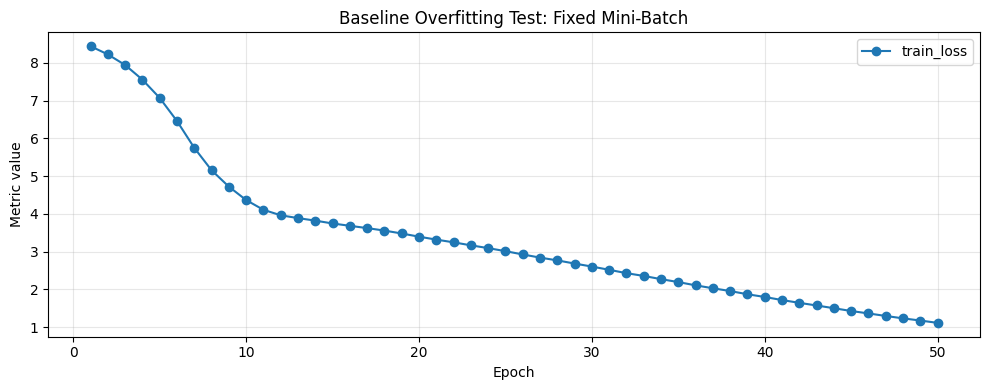

In [171]:
plot_training_curves(baseline_overfit_history, metrics=["train_loss"], title="Baseline Overfitting Test: Fixed Mini-Batch")
plt.show()

In [172]:
overfit_model.eval()
with torch.no_grad():
    generated_after_overfit = overfit_model.generate(fixed_check_batch["images"][:4], max_len=baseline_cfg.max_decode_len)

comparison_rows = []
for i in range(4):
    comparison_rows.append({
        "image_id": fixed_check_batch["image_ids"][i],
        "reference_caption": fixed_check_batch["raw_captions"][i],
        "generated_before": dm.vocab.decode(generated_before_overfit[i]),
        "generated_after": dm.vocab.decode(generated_after_overfit[i]),
    })

baseline_overfit_examples = pd.DataFrame(comparison_rows)
baseline_overfit_examples

,image_id,reference_caption,generated_before,generated_after
0,2264316030_600e55748d.jpg,A brown and black dog walks in the snow with its tongue hanging out .,prizes mantle couples for puckering halter active unfinished carrying covers pulling prisoner parka learns lasso squ...,a man climbing pauses to <unk> his route
1,140526327_3cb984de09.jpg,A man rock climbing pauses to calculate his route .,prizes mantle stuff schoolgirls vault dj dj map chickens lighted tackle blood licking exiting licking exiting onlook...,a man climbing pauses to <unk> his route
2,3172280520_e7655fb596.jpg,A bald man is posing with two smiling girls .,prizes mantle couples for puckering halter active unfinished carrying covers pulling prisoner parka learns lasso squ...,a man wearing black speaks into a microphone while a woman writes
3,300371487_daec5d11ab.jpg,A dog chasing a pink ball .,prizes mantle couples for puckering halter active unfinished carrying covers pulling prisoner parka learns lasso squ...,a man climbing pauses to <unk> his route


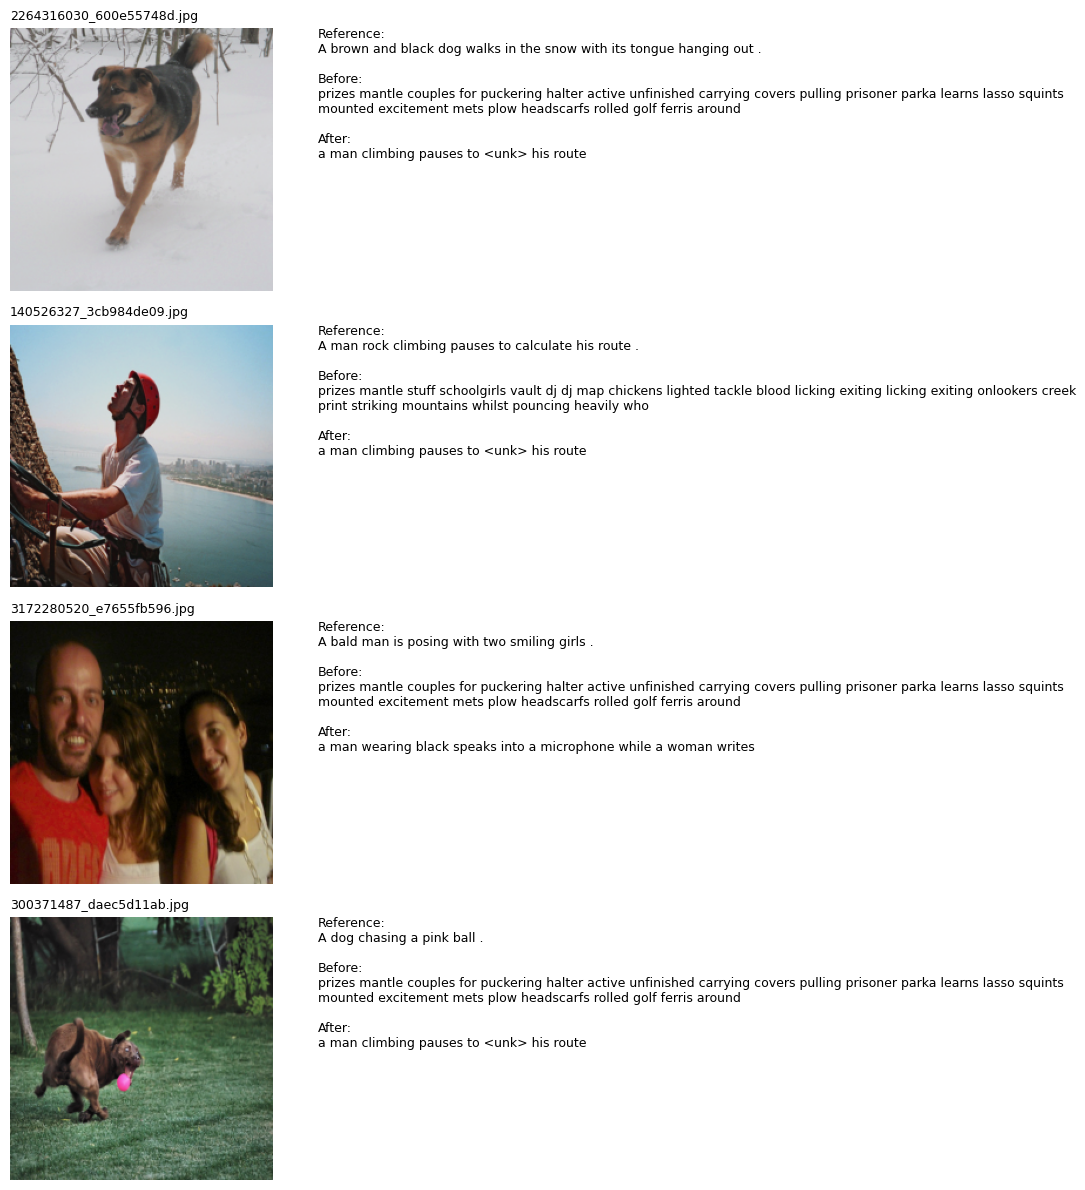

In [173]:
fig, axes = plt.subplots(4, 2, figsize=(12, 12), width_ratios=[1.0, 1.35])
for i, row_axes in enumerate(axes):
    image_ax, text_ax = row_axes
    image_ax.imshow(unnormalize_image(fixed_check_batch["images"][i]).permute(1, 2, 0).cpu())
    image_ax.axis("off")
    image_ax.set_title(fixed_check_batch["image_ids"][i], fontsize=9, loc="left")

    text = (
        f"Reference:\n{fixed_check_batch['raw_captions'][i]}\n\n"
        f"Before:\n{dm.vocab.decode(generated_before_overfit[i])}\n\n"
        f"After:\n{dm.vocab.decode(generated_after_overfit[i])}"
    )
    text_ax.axis("off")
    text_ax.text(0.0, 1.0, text, va="top", ha="left", fontsize=9, wrap=True)
fig.tight_layout()
plt.show()


### 6.9 Vorsichtige Interpretation

Wenn die Loss-Kurve klar fällt, zeigt dieser Test, dass Encoder-Ausgabe, Decoder, Padding-Maskierung im Loss und Optimizer auf einem fixen Mini-Batch grundsätzlich zusammenarbeiten. Wenn die generierten Captions nach dem Test näher an den Referenzen liegen, spricht das zusätzlich dafür, dass der Decoder Informationen aus dem Batch memorisieren kann.

Dieser Test sagt ausdrücklich nicht aus, dass die Baseline generalisiert, dass BLEU/CLIPScore gut sein werden oder dass spätere Attention-Heatmaps korrekt sind. Dafür braucht es separate Validierung, qualitative Beispiele und einen fairen Vergleich gegen die Attention-Variante.

> **Key Takeaway:** Die CNN-LSTM-Baseline ist jetzt als prüfbarer Vergleichspunkt vorbereitet. Der nächste Schritt ist erst dann vollständiges Training, wenn dieser Mini-Batch-Test plausibel sinkenden Loss zeigt.

## 7 Baseline-Training und erste Evaluation

Nach dem Overfitting-Test ist ein echter Train/Val-Lauf nötig, weil Memorization auf einem fixen Mini-Batch keine Generalisierung zeigt. Diese Sektion trainiert die CNN-LSTM-Baseline erstmals mit Train- und Validation-Dataloader, speichert den besten Checkpoint nach `val_loss` und berechnet erste Greedy-Decoding-Metriken.

Die Resultate sind ein Zwischenstand. Der Lauf ist bewusst kurz und ressourcenschonend, damit er im Notebook praktikabel bleibt. Diese Baseline ist später der Referenzpunkt für die Attention-Variante: Der Vergleich ist nur fair, wenn Splits, Preprocessing, Batch Size, Lernrate und Trainingsbudget transparent dokumentiert sind.

### 7.1 Trainingskonfiguration

Die Startwerte orientieren sich am erfolgreichen Overfitting-Test, sind aber für einen kurzen Train/Val-Lauf begrenzt. `resnet18` und `freeze_encoder=True` halten den Lauf auf CPU/MPS klein. `learning_rate=1e-3` und `weight_decay=0.0` übernehmen wir bewusst aus dem Overfitting-Test, damit nicht mehrere Faktoren gleichzeitig geändert werden. Eine grössere Batch Size würde weniger Updates pro Epoche bedeuten; deshalb bleibt `batch_size=32` als bereits geprüfter Pipeline-Wert erhalten.

Für eine Abgabe oder ein späteres vollständigeres Experiment bleibt `RUN_BASELINE_TRAINING` standardmässig `False`. Wenn kein Checkpoint existiert, gibt das Notebook eine klare Meldung aus statt stillschweigend neu lange zu trainieren.

In [ ]:
try:
    from lightning.pytorch.callbacks import ModelCheckpoint
except ImportError:
    from pytorch_lightning.callbacks import ModelCheckpoint

from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu


@dataclass
class BaselineTrainConfig:
    run_id: str = "baseline_cnn_lstm_first_run"
    max_epochs: int = 3
    batch_size: int = 32
    learning_rate: float = 1e-3
    weight_decay: float = 0.0
    freeze_encoder: bool = True
    encoder_name: str = "resnet18"
    num_workers: int = 0
    precision: str = "32-true"
    gradient_clip_val: float = 1.0
    deterministic: bool = True
    log_every_n_steps: int = 25
    limit_train_batches: Optional[int] = 50  # Set to None for a fuller run.
    limit_val_batches: Optional[int] = 20    # Set to None for full validation.
    bleu_eval_num_images: int = 150
    qualitative_num_images: int = 6


baseline_train_cfg = BaselineTrainConfig()
RUN_BASELINE_TRAINING = False
asdict(baseline_train_cfg)

### 7.2 DataModule und Modell für den Baseline-Lauf

Für diesen Lauf wird das DataModule mit den Trainingsparametern aus `BaselineTrainConfig` neu instanziiert. Das vermeidet versteckte Änderungen an Batch Size oder Worker-Zahl. Die Modellkonfiguration wird ebenfalls explizit aus der Trainingskonfiguration und dem Vocabulary abgeleitet.

In [ ]:
baseline_train_data_cfg = data_cfg
baseline_train_loader_cfg = TrainConfig(
    batch_size=baseline_train_cfg.batch_size,
    num_workers=baseline_train_cfg.num_workers,
    pin_memory=False,
)

baseline_dm = Flickr8kDataModule(data_cfg=baseline_train_data_cfg, train_cfg=baseline_train_loader_cfg)
baseline_dm.setup()

baseline_train_model_cfg = BaselineConfig(
    encoder_name=baseline_train_cfg.encoder_name,
    pretrained=True,
    freeze_encoder=baseline_train_cfg.freeze_encoder,
    embed_dim=baseline_cfg.embed_dim,
    hidden_dim=baseline_cfg.hidden_dim,
    num_layers=baseline_cfg.num_layers,
    dropout=baseline_cfg.dropout,
    learning_rate=baseline_train_cfg.learning_rate,
    weight_decay=baseline_train_cfg.weight_decay,
    max_decode_len=baseline_cfg.max_decode_len,
    pad_idx=baseline_dm.vocab.pad_idx,
    start_idx=baseline_dm.vocab.start_idx,
    end_idx=baseline_dm.vocab.end_idx,
    vocab_size=len(baseline_dm.vocab),
)

asdict(baseline_train_model_cfg)

### 7.3 Checkpointing und Loss-History

Der beste Checkpoint wird über `val_loss` bestimmt, nicht über die letzte Epoche. Für diesen kurzen Testlauf verzichten wir bewusst auf EarlyStopping, weil nur wenige Epochen laufen und wir die Kurven zuerst sehen wollen.

In [ ]:
class EpochLossHistoryCallback(Callback):
    """Collect epoch-level train and validation losses."""

    def __init__(self):
        super().__init__()
        self.train_loss: list[float] = []
        self.val_loss: list[float] = []

    def on_train_epoch_end(self, trainer, pl_module) -> None:
        value = trainer.callback_metrics.get("train_loss")
        if value is not None:
            self.train_loss.append(float(value.detach().cpu()))

    def on_validation_epoch_end(self, trainer, pl_module) -> None:
        value = trainer.callback_metrics.get("val_loss")
        if value is not None and trainer.sanity_checking is False:
            self.val_loss.append(float(value.detach().cpu()))


baseline_checkpoint_dir = PROJECT_ROOT / "checkpoints" / "baseline"
baseline_checkpoint_dir.mkdir(parents=True, exist_ok=True)

baseline_checkpoint_callback = ModelCheckpoint(
    dirpath=baseline_checkpoint_dir,
    filename="baseline-cnn-lstm-{epoch:02d}-{val_loss:.3f}",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)
baseline_history_callback = EpochLossHistoryCallback()

### 7.4 Training starten oder vorhandenen Checkpoint laden

Diese Zelle startet nur dann Training, wenn `RUN_BASELINE_TRAINING=True` gesetzt ist. Bei `False` sucht sie nach einem vorhandenen Checkpoint in `checkpoints/baseline/`. So bleibt das Notebook nachvollziehbar, ohne beim Öffnen automatisch ein Training anzustossen.

In [ ]:
def latest_checkpoint(checkpoint_dir: Path) -> Optional[Path]:
    candidates = sorted(checkpoint_dir.glob("*.ckpt"), key=lambda p: p.stat().st_mtime)
    return candidates[-1] if candidates else None


def trainer_limit_value(value: Optional[int]):
    return value if value is not None else 1.0


baseline_trained_model: Optional[BaselineCaptioningModule] = None
baseline_best_checkpoint_path: Optional[str] = None
baseline_best_val_loss: Optional[float] = None
baseline_training_history = {"train_loss": [], "val_loss": []}

if RUN_BASELINE_TRAINING:
    baseline_trained_model = BaselineCaptioningModule(baseline_train_model_cfg)
    baseline_accelerator = "mps" if torch.backends.mps.is_available() else "cpu"
    baseline_trainer = pl.Trainer(
        max_epochs=baseline_train_cfg.max_epochs,
        accelerator=baseline_accelerator,
        devices=1,
        logger=False,
        enable_checkpointing=True,
        callbacks=[baseline_checkpoint_callback, baseline_history_callback],
        deterministic=baseline_train_cfg.deterministic,
        precision=baseline_train_cfg.precision,
        gradient_clip_val=baseline_train_cfg.gradient_clip_val,
        log_every_n_steps=baseline_train_cfg.log_every_n_steps,
        limit_train_batches=trainer_limit_value(baseline_train_cfg.limit_train_batches),
        limit_val_batches=trainer_limit_value(baseline_train_cfg.limit_val_batches),
    )
    baseline_trainer.fit(
        baseline_trained_model,
        train_dataloaders=baseline_dm.train_dataloader(),
        val_dataloaders=baseline_dm.val_dataloader(),
    )
    baseline_best_checkpoint_path = baseline_checkpoint_callback.best_model_path
    baseline_best_val_loss = float(baseline_checkpoint_callback.best_model_score.detach().cpu())
    baseline_training_history = {
        "train_loss": baseline_history_callback.train_loss,
        "val_loss": baseline_history_callback.val_loss,
    }
    # Evaluate the best validation checkpoint, not implicitly the last epoch.
    baseline_trained_model = BaselineCaptioningModule.load_from_checkpoint(
        baseline_best_checkpoint_path,
        cfg=baseline_train_model_cfg,
        map_location="cpu",
    )
else:
    checkpoint = latest_checkpoint(baseline_checkpoint_dir)
    if checkpoint is None:
        print("No baseline checkpoint found. Set RUN_BASELINE_TRAINING=True to run the short baseline training cell.")
    else:
        baseline_best_checkpoint_path = str(checkpoint)
        baseline_trained_model = BaselineCaptioningModule.load_from_checkpoint(
            checkpoint,
            cfg=baseline_train_model_cfg,
            map_location="cpu",
        )
        metrics_path = PROJECT_ROOT / "outputs" / "baseline_first_run_metrics.json"
        if metrics_path.exists():
            stored_metrics = load_json(metrics_path)
            baseline_best_val_loss = stored_metrics.get("best_val_loss")
            baseline_training_history = stored_metrics.get("history", baseline_training_history)
        else:
            match = re.search(r"val_loss=([0-9]+(?:\.[0-9]+)?)", checkpoint.name)
            baseline_best_val_loss = float(match.group(1)) if match else None
        print(f"Loaded baseline checkpoint: {baseline_best_checkpoint_path}")

print("best checkpoint:", baseline_best_checkpoint_path)
print("best val_loss:", baseline_best_val_loss)

### 7.5 Trainingskurven

Die Kurven sind bei wenigen Epochen und begrenzten Batches nur als erster Funktionstest zu verstehen. Sinkende Train-Loss-Werte zeigen, dass Optimierung läuft; Val-Loss muss vorsichtig interpretiert werden, weil der Lauf kurz ist und die Validierung hier aus Ressourcengründen optional begrenzt sein kann.

In [ ]:
if baseline_training_history["train_loss"] or baseline_training_history["val_loss"]:
    plot_training_curves(
        baseline_training_history,
        metrics=[m for m in ["train_loss", "val_loss"] if baseline_training_history.get(m)],
        title="Baseline CNN-LSTM: First Train/Val Run",
    )
    plt.show()
else:
    print("No training history available yet. Run training or load metrics JSON with stored history.")

### 7.6 BLEU auf einem kleinen Validation-Subset

BLEU misst n-Gram-Überlappung zwischen generierter Caption und Referenzen. Für Image Captioning ist das nur eine begrenzte Qualitätsmessung: Eine semantisch passende Caption kann niedrigen BLEU erhalten, wenn sie anders formuliert ist. Wichtig ist hier, mehrere Referenzcaptions pro Bild zu verwenden.

In [ ]:
def decode_caption_ids(vocab: Vocabulary, token_ids: Union[list[int], torch.Tensor]) -> str:
    """Decode generated token ids while hiding padding/start/end tokens."""
    return vocab.decode(token_ids, skip_special_tokens=True).strip()


def evaluate_greedy_bleu(
    model: BaselineCaptioningModule,
    dm: Flickr8kDataModule,
    num_images: int = 150,
    batch_size: int = 32,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Generate captions for unique validation images and compute BLEU-1..4."""
    model.eval()
    device = next(model.parameters()).device

    val_unique = dm.annotations[dm.annotations["split"] == "val"].drop_duplicates("image_id").reset_index(drop=True)
    val_subset = val_unique.head(min(num_images, len(val_unique))).copy()
    eval_dataset = Flickr8kCaptionDataset(
        val_subset,
        dm.vocab,
        transform=build_eval_transforms(dm.data_cfg.image_size),
        max_caption_len=dm.data_cfg.max_caption_len,
    )
    eval_loader = DataLoader(
        eval_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=make_caption_collate_fn(dm.vocab.pad_idx),
    )

    rows = []
    all_references = []
    all_hypotheses = []
    smoothing = SmoothingFunction().method1

    with torch.no_grad():
        for batch in eval_loader:
            images = batch["images"].to(device)
            generated_ids = model.generate(images, max_len=baseline_train_model_cfg.max_decode_len).cpu()
            for image_id, gen_ids in zip(batch["image_ids"], generated_ids):
                generated_caption = decode_caption_ids(dm.vocab, gen_ids)
                refs = dm.reference_captions[image_id]
                ref_tokens = [tokenize_caption(ref) for ref in refs]
                hyp_tokens = tokenize_caption(generated_caption)
                if not hyp_tokens:
                    hyp_tokens = ["<empty>"]
                all_references.append(ref_tokens)
                all_hypotheses.append(hyp_tokens)
                rows.append({
                    "image_id": image_id,
                    "generated_caption": generated_caption,
                    "references": refs,
                })

    bleu_scores = {
        "BLEU-1": corpus_bleu(all_references, all_hypotheses, weights=(1.0, 0, 0, 0), smoothing_function=smoothing),
        "BLEU-2": corpus_bleu(all_references, all_hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing),
        "BLEU-3": corpus_bleu(all_references, all_hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothing),
        "BLEU-4": corpus_bleu(all_references, all_hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing),
    }
    return pd.DataFrame(rows), pd.DataFrame([bleu_scores])


if baseline_trained_model is None:
    baseline_val_predictions = pd.DataFrame()
    baseline_bleu_table = pd.DataFrame()
    print("No trained baseline model available for BLEU evaluation.")
else:
    eval_device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    baseline_trained_model = baseline_trained_model.to(eval_device)
    baseline_val_predictions, baseline_bleu_table = evaluate_greedy_bleu(
        baseline_trained_model,
        baseline_dm,
        num_images=baseline_train_cfg.bleu_eval_num_images,
        batch_size=baseline_train_cfg.batch_size,
    )
    display(baseline_bleu_table)

### 7.7 Qualitative Validierungsbeispiele

Die Beispiele zeigen, welche Fehler die Baseline in diesem frühen Stadium macht. Einzelbeispiele sind nicht repräsentativ für die Gesamtqualität, helfen aber, typische Muster wie zu generische Captions oder wiederholte Phrasen zu erkennen.

In [ ]:
def show_baseline_validation_examples(predictions: pd.DataFrame, dm: Flickr8kDataModule, n: int = 6) -> None:
    if predictions.empty:
        print("No predictions available to display.")
        return
    rows = predictions.head(n)
    fig, axes = plt.subplots(len(rows), 2, figsize=(12, 3.4 * len(rows)), width_ratios=[1.0, 1.45])
    if len(rows) == 1:
        axes = np.array([axes])

    image_dir = Path(dm.paths["image_dir"])
    for row_axes, (_, row) in zip(axes, rows.iterrows()):
        image_ax, text_ax = row_axes
        image_path = image_dir / row["image_id"]
        image_ax.imshow(Image.open(image_path).convert("RGB"))
        image_ax.axis("off")
        image_ax.set_title(row["image_id"], fontsize=9, loc="left")

        refs = row["references"][:5]
        ref_text = "\n".join(f"- {ref}" for ref in refs)
        text = f"Generated:\n{row['generated_caption']}\n\nReferences:\n{ref_text}"
        text_ax.axis("off")
        text_ax.text(0.0, 1.0, text, va="top", ha="left", fontsize=9, wrap=True)
    fig.tight_layout()
    plt.show()


show_baseline_validation_examples(
    baseline_val_predictions,
    baseline_dm,
    n=baseline_train_cfg.qualitative_num_images,
)

### 7.8 Resultat-Tabelle und Speichern

Die Tabelle dokumentiert, warum dieser Run später mit der Attention-Variante verglichen werden kann: gleiche Datenpipeline, gleiche Splits, gleiche Grundarchitektur ausser Attention und transparente Hyperparameter. Die Werte sind ein erster Zwischenstand und kein finales Resultat.

In [ ]:
def safe_float(value: Any) -> Optional[float]:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    return float(value)


baseline_bleu_scores = baseline_bleu_table.iloc[0].to_dict() if not baseline_bleu_table.empty else {}
results_row = {
    "run_id": baseline_train_cfg.run_id,
    "model": "CNN-LSTM Baseline",
    "encoder": baseline_train_cfg.encoder_name,
    "freeze_encoder": baseline_train_cfg.freeze_encoder,
    "epochs": baseline_train_cfg.max_epochs,
    "lr": baseline_train_cfg.learning_rate,
    "batch_size": baseline_train_cfg.batch_size,
    "best_val_loss": baseline_best_val_loss,
    "BLEU-1": baseline_bleu_scores.get("BLEU-1"),
    "BLEU-2": baseline_bleu_scores.get("BLEU-2"),
    "BLEU-3": baseline_bleu_scores.get("BLEU-3"),
    "BLEU-4": baseline_bleu_scores.get("BLEU-4"),
    "comment": "First short baseline run; reference point for later attention comparison.",
}

baseline_results_table = pd.DataFrame([results_row])
display(baseline_results_table)

outputs_dir = PROJECT_ROOT / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

baseline_metrics = {
    "run_id": baseline_train_cfg.run_id,
    "config": asdict(baseline_train_cfg),
    "model_config": asdict(baseline_train_model_cfg),
    "best_checkpoint_path": baseline_best_checkpoint_path,
    "best_val_loss": safe_float(baseline_best_val_loss),
    "history": baseline_training_history,
    "bleu": {k: safe_float(v) for k, v in baseline_bleu_scores.items()},
}

save_json(baseline_metrics, outputs_dir / "baseline_first_run_metrics.json")
baseline_results_table.to_csv(outputs_dir / "results_summary.csv", index=False)

if not baseline_val_predictions.empty:
    examples_payload = baseline_val_predictions.head(baseline_train_cfg.qualitative_num_images).to_dict(orient="records")
    save_json(examples_payload, outputs_dir / "baseline_first_run_examples.json")

print("Saved metrics to:", outputs_dir / "baseline_first_run_metrics.json")
print("Saved summary to:", outputs_dir / "results_summary.csv")

### 7.9 Key Takeaway

- Die CNN-LSTM-Baseline kann jetzt nicht nur einen Mini-Batch overfitten, sondern auch in einem kurzen Train/Val-Setup mit Checkpointing nach `best val_loss` laufen.
- Greedy-Decoding, BLEU-1 bis BLEU-4 und qualitative Validierungsbeispiele sind vorbereitet.
- Offen bleiben längeres Training, stabilere Hyperparameter, mehrere Seeds und der eigentliche Vergleich gegen eine Attention-Variante.
- Diese Baseline ist ein fairer Vergleichspunkt, weil Datenpipeline, Splits, Preprocessing und Trainingskonfiguration explizit dokumentiert sind.
- Die erste Evaluation ist limitiert: wenige Epochen, optional begrenzte Batches, Greedy-Decoding und BLEU als nur grobe n-Gram-Metrik.